In [1]:
# Imports 
import torch
import torchvision
from torch import nn 
from sklearn.metrics import * 
from sklearn import metrics
from dataset import create_dataloaders
import warnings

In [2]:
# Get the device to be tested on 
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Load in the testing data 
DATA_PATH = "/home/ec2-user/SageMaker/data/"
train_path = DATA_PATH + "processed/train"
val_path = DATA_PATH + "processed/val"
test_path = DATA_PATH + "processed/test"

_, _, test_dataloader, train_data, _, test_data = create_dataloaders(train_path, val_path, test_path)

In [4]:
# Load in the trained model 
model = torchvision.models.resnet18(weights=None)

model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features=model.fc.in_features,
              out_features=len(train_data.classes))
).to(device)

model.load_state_dict(torch.load('model_v3.pth'))
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
def test(model, test_dataloader, device):

    predicted_letter_list = []
    letter_list = []

    model.eval()

    with torch.inference_mode():
        for sign, letter in test_dataloader:
            sign = sign.to(device)
            letter = letter.to(device)

            output = model(sign)

            predicted = output.argmax(dim=1)

            predicted_letter_list.extend(predicted.cpu().tolist())
            letter_list.extend(letter.cpu().tolist())

    return predicted_letter_list, letter_list 
            

In [6]:
# Test model performance on the test set 
predicted_letter_list, letter_list = test(model, test_dataloader, device)

warnings.filterwarnings(
    "ignore",
    message="The number of unique classes is greater than 50% of the number of samples.*"
)

# Calculate the metrics 
accuracy = accuracy_score(letter_list, predicted_letter_list) * 100
precision = precision_score(letter_list, predicted_letter_list, average="macro") * 100
recall = recall_score(letter_list, predicted_letter_list, average="macro") * 100
f1 = f1_score(letter_list, predicted_letter_list, average="macro") * 100


# Display the precision, recall, f1, and accuracy 
print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1-Score: {f1:.2f}%")


Accuracy: 99.99%
Precision: 99.99%
Recall: 99.99%
F1-Score: 99.99%


In [7]:
print(classification_report(
    letter_list,
    predicted_letter_list,
    target_names=test_data.classes,
    zero_division=0
))

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       300
           B       1.00      1.00      1.00       300
           C       1.00      1.00      1.00       300
           D       1.00      1.00      1.00       300
           E       1.00      1.00      1.00       300
           F       1.00      1.00      1.00       300
           G       1.00      1.00      1.00       300
           H       1.00      1.00      1.00       300
           I       1.00      1.00      1.00       300
           J       1.00      1.00      1.00       300
           K       1.00      1.00      1.00       300
           L       1.00      1.00      1.00       300
           M       1.00      1.00      1.00       300
           N       1.00      1.00      1.00       300
           O       1.00      1.00      1.00       300
           P       1.00      1.00      1.00       300
           Q       1.00      1.00      1.00       300
           R       1.00    

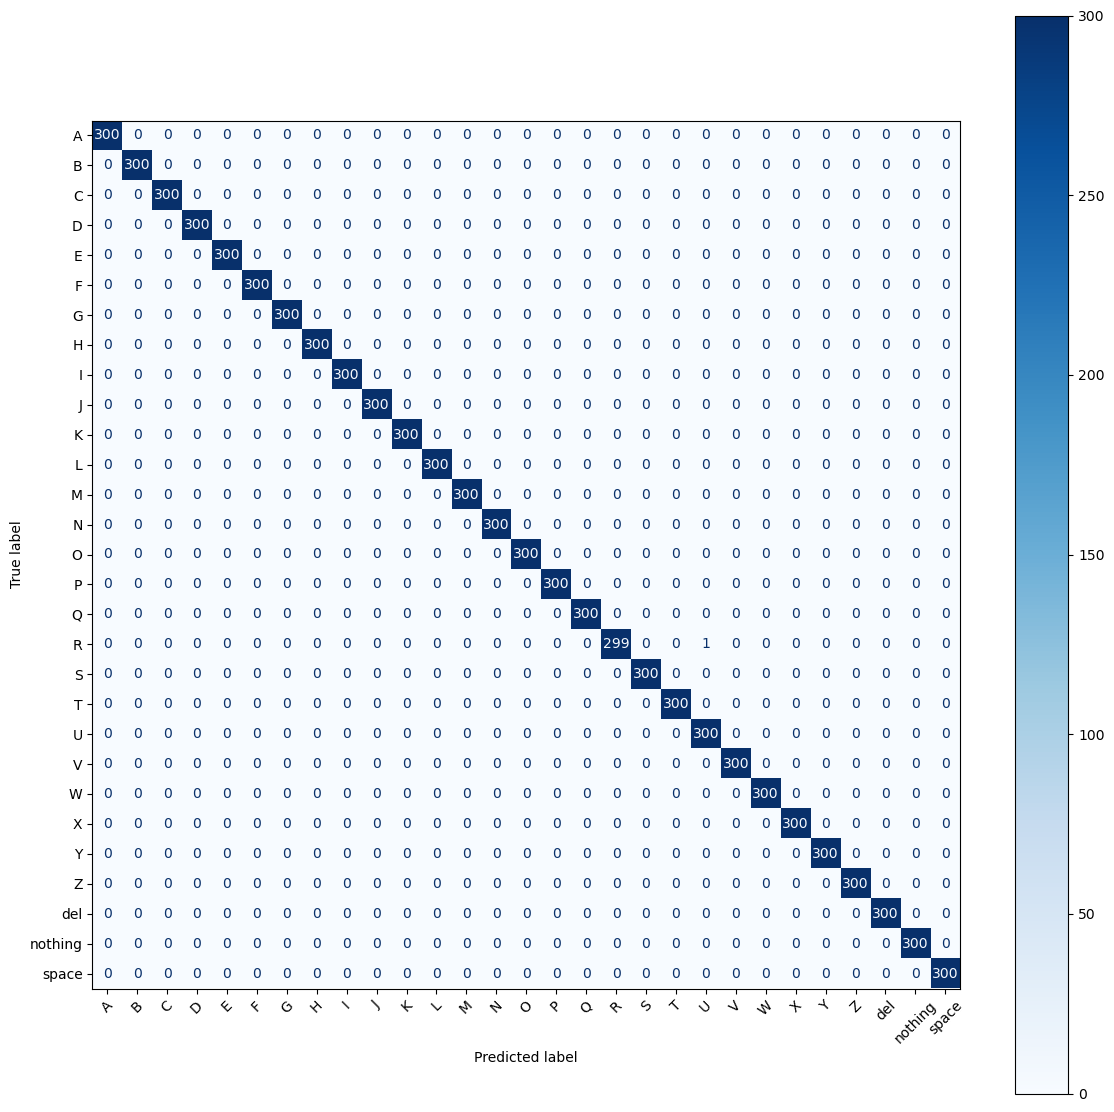

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

figure, axis = plt.subplots(figsize=(14, 14))


display = ConfusionMatrixDisplay.from_predictions(
    letter_list,
    predicted_letter_list,
    display_labels=test_data.classes,
    ax=axis,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d"
)